# Duration Leakage Audit

The reference M0 design centers the candidate window on `estimated_end_date`, which is built from
`declared_duration_months` - the same covariate the survival models test. This audit checks how
much that design choice drives the results, by comparing:

1. **balanced_reference** - the official design;
2. **no_temporal_score_reference_pool** - same candidate pool, but re-ranked with the temporal
   score removed (text/CPV/buyer weights renormalized);
3. **forward_24m_no_duration** - a broad forward window from publication (no duration used at all).

**Running this notebook regenerates** the two alternative link/survival datasets and
`duration_leakage_*` tables. Shared M0 machinery is imported from `scripts/`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from lifelines import CoxPHFitter
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
import build_m0_candidate_pairs as bmcp
import run_m0_linkage as rml

P = PROJECT_ROOT / "data" / "processed"
T = PROJECT_ROOT / "reports" / "tables"
T.mkdir(parents=True, exist_ok=True)

# Composite weights with the temporal score removed, renormalized.
NO_TIME_W = {"s_text": bmcp.W_TEXT / (bmcp.W_TEXT + bmcp.W_CPV + bmcp.W_BUYER),
             "s_cpv": bmcp.W_CPV / (bmcp.W_TEXT + bmcp.W_CPV + bmcp.W_BUYER),
             "s_buyer": bmcp.W_BUYER / (bmcp.W_TEXT + bmcp.W_CPV + bmcp.W_BUYER)}
print(NO_TIME_W)

{'s_text': 0.46666666666666673, 's_cpv': 0.4, 's_buyer': 0.13333333333333336}


## Load sources, candidate pairs, and the balanced reference

In [2]:
dtype = {c: str for c in ["notice_id", "buyer_key", "buyer_key_type", "buyer_name_normalized",
                          "buyer_siret_clean", "buyer_siren_clean", "objet_clean", "cpv_clean",
                          "cpv_division", "cpv_category", "cpv_class", "cpv_group", "category_label"]}
allsrc = pd.read_csv(P / "boamp_m0_sources.csv", dtype=dtype,
                     parse_dates=["publication_date", "start_date", "estimated_end_date", "study_end_date"],
                     low_memory=False)
elig = allsrc[allsrc.buyer_key_type != "MISSING"].sort_values(
    ["buyer_key", "publication_date"]).reset_index(drop=True)
pairs = pd.read_csv(P / "boamp_m0_candidate_pairs.csv",
                    dtype={"source_notice_id": str, "candidate_notice_id": str},
                    parse_dates=["source_date", "candidate_date", "expected_end_date"], low_memory=False)
ref = pd.read_csv(P / "boamp_m0_links_balanced.csv",
                  dtype={"source_notice_id": str, "candidate_notice_id": str},
                  parse_dates=["source_date", "candidate_date", "expected_end_date"], low_memory=False)
ref_keys = set(zip(ref.source_notice_id, ref.candidate_notice_id))
ref_src = set(ref.source_notice_id)
print(f"sources: {len(allsrc)} | eligible: {len(elig)} | pairs: {len(pairs)} | reference links: {len(ref)}")

sources: 3159 | eligible: 3159 | pairs: 6137 | reference links: 618


## Helpers: alternative linkers, summary metrics, and the Cox duration effect

In [3]:
def make_links_from_pairs(pairs, name, score_col):
    x = pairs.sort_values(["source_notice_id", score_col], ascending=[True, False]).copy()
    x["candidate_rank"] = x.groupby("source_notice_id").cumcount() + 1
    r1 = x[x.candidate_rank == 1].copy()
    thr = r1[score_col].quantile(.5)
    links = r1[r1[score_col] >= thr].copy()
    links["m0_composite_score"] = links[score_col]
    links["variant"] = name
    links["threshold_used"] = thr
    return links, thr


def forward_pairs(src, tfidf, months=24):
    """Broad forward window from publication; scoring uses no duration/temporal signal."""
    ids = src.notice_id.to_numpy(); pub = src.publication_date.to_numpy()
    bk = src.buyer_key.to_numpy(object); bkt = src.buyer_key_type.to_numpy(object)
    main = src.cpv_clean.to_numpy(object); cat = src.cpv_category.to_numpy(object)
    cls = src.cpv_class.to_numpy(object); grp = src.cpv_group.to_numpy(object)
    div = src.cpv_division.to_numpy(object); gen = src.cpv_generic_flag.to_numpy()
    rec = []
    maxcand = 30
    for _, idx in src.groupby("buyer_key", sort=False).indices.items():
        idx = np.asarray(idx); gp = pub[idx]; n = len(idx)
        if n < 2:
            continue
        for i in range(n):
            hi = gp[i] + np.timedelta64(int(round(months * 30.44)), "D")
            loc = np.where((gp > gp[i]) & (gp <= hi))[0]
            if len(loc) == 0:
                continue
            glob = idx[loc]
            gaps = (gp[loc] - gp[i]) / np.timedelta64(1, "D") / 30.44
            if len(loc) > maxcand:
                keep = np.argsort(gaps)[:maxcand]
                loc = loc[keep]; glob = glob[keep]; gaps = gaps[keep]
            sims = tfidf[glob].dot(tfidf[idx[i]].T).toarray().ravel()
            sb = bmcp.BUYER_KEY_TYPE_SCORE.get(bkt[idx[i]], 0.0)
            for k, cg in enumerate(glob):
                scpv = bmcp.cpv_pair_score(main[idx[i]], main[cg], cat[idx[i]], cat[cg],
                                           cls[idx[i]], cls[cg], grp[idx[i]], grp[cg],
                                           div[idx[i]], div[cg])
                stext = float(sims[k])
                score = NO_TIME_W["s_text"] * stext + NO_TIME_W["s_cpv"] * scpv + NO_TIME_W["s_buyer"] * sb
                rec.append(dict(source_notice_id=ids[idx[i]], candidate_notice_id=ids[cg],
                                source_date=gp[i], candidate_date=gp[loc[k]],
                                buyer_key=bk[idx[i]], buyer_key_type=bkt[idx[i]],
                                gap_months=gaps[k], expected_end_date=pd.NaT,
                                abs_gap_to_expected_end=np.nan, s_time=np.nan,
                                s_text=stext, s_cpv=scpv, s_buyer=sb, m0_composite_score=score,
                                cpv_missing=bool(pd.isna(main[idx[i]]) or pd.isna(main[cg])),
                                cpv_generic_flag=bool(gen[idx[i]] or gen[cg]),
                                score_forward_no_duration=score))
    out = pd.DataFrame(rec)
    if len(out):
        out = out.sort_values(["source_notice_id", "score_forward_no_duration"], ascending=[True, False])
        out["candidate_rank"] = out.groupby("source_notice_id").cumcount() + 1
        out["n_candidates_for_source"] = out.groupby("source_notice_id").candidate_notice_id.transform("count")
        top2 = out[out.candidate_rank <= 2].pivot(index="source_notice_id", columns="candidate_rank",
                                                  values="score_forward_no_duration")
        out["top1_top2_margin"] = out.source_notice_id.map((top2.get(1) - top2.get(2)).fillna(top2.get(1)))
    return out


def summarize(name, links, allsrc, ref_keys, ref_src):
    links.to_csv(P / f"boamp_m0_links_{name}.csv", index=False)
    surv = rml.build_survival_dataset(allsrc, links, name)
    surv.to_csv(P / f"boamp_survival_m0_{name}.csv", index=False)
    keys = set(zip(links.source_notice_id, links.candidate_notice_id))
    src = set(links.source_notice_id)
    cnt = links.candidate_notice_id.value_counts()
    return surv, dict(
        variant=name, n_links=len(links),
        event_rate=len(links) / len(allsrc[allsrc.buyer_key_type != "MISSING"]),
        jaccard_vs_reference=len(keys & ref_keys) / len(keys | ref_keys) if keys | ref_keys else np.nan,
        event_status_changes_vs_reference=len(src ^ ref_src),
        n_reused_candidates=int((cnt > 1).sum()),
        max_candidate_multiplicity=int(cnt.max()) if len(cnt) else 0,
        observed_duration_event_rate=surv.loc[~surv.dur_was_imputed, "event"].mean(),
        imputed_duration_event_rate=surv.loc[surv.dur_was_imputed, "event"].mean(),
        median_event_time=surv.loc[surv.event == 1, "time_to_event_or_censor_months"].median())


def cox_duration(surv, name):
    df = surv[["time_to_event_or_censor_months", "event", "declared_duration_months",
               "dur_was_imputed", "buyer_key"]].dropna().copy()
    df["log_duration"] = np.log1p(df.declared_duration_months)
    df["dur_was_imputed"] = df.dur_was_imputed.astype(int)
    rows = []
    for robust in [False, True]:
        try:
            c = CoxPHFitter()
            cols = ["time_to_event_or_censor_months", "event", "log_duration", "dur_was_imputed"] + (
                ["buyer_key"] if robust else [])
            c.fit(df[cols], duration_col="time_to_event_or_censor_months", event_col="event",
                  cluster_col="buyer_key" if robust else None, robust=robust)
            for term, r in c.summary.iterrows():
                rows.append(dict(variant=name, model="cox_duration_clustered" if robust else "cox_duration",
                                 term=term, coef=r.coef, exp_coef=r["exp(coef)"], p=r.p,
                                 ci_lower=r["exp(coef) lower 95%"], ci_upper=r["exp(coef) upper 95%"]))
        except Exception as e:
            rows.append(dict(variant=name, model="cox_duration_clustered" if robust else "cox_duration",
                             term="ERROR", coef=np.nan, exp_coef=np.nan, p=np.nan,
                             ci_lower=np.nan, ci_upper=np.nan, error=str(e)))
    return rows

## 1. Balanced reference (baseline row)

In [4]:
rows = []
cox = []
ref_surv = pd.read_csv(P / "boamp_survival_m0_balanced.csv",
                       parse_dates=["publication_date", "start_date", "estimated_end_date", "study_end_date"],
                       low_memory=False)
rows.append(dict(variant="balanced_reference", n_links=len(ref), event_rate=len(ref) / len(elig),
                 jaccard_vs_reference=1, event_status_changes_vs_reference=0,
                 n_reused_candidates=int((ref.candidate_notice_id.value_counts() > 1).sum()),
                 max_candidate_multiplicity=int(ref.candidate_notice_id.value_counts().max()),
                 observed_duration_event_rate=ref_surv.loc[~ref_surv.dur_was_imputed, "event"].mean(),
                 imputed_duration_event_rate=ref_surv.loc[ref_surv.dur_was_imputed, "event"].mean(),
                 median_event_time=ref_surv.loc[ref_surv.event == 1, "time_to_event_or_censor_months"].median()))
cox += cox_duration(ref_surv, "balanced_reference")

## 2. Same candidate pool, temporal score removed

In [5]:
nt = pairs.copy()
nt["score_no_temporal"] = NO_TIME_W["s_text"] * nt.s_text + NO_TIME_W["s_cpv"] * nt.s_cpv + NO_TIME_W["s_buyer"] * nt.s_buyer
nt_links, thr = make_links_from_pairs(nt, "no_temporal_score_reference_pool", "score_no_temporal")
surv, s = summarize("no_temporal_score_reference_pool", nt_links, allsrc, ref_keys, ref_src)
rows.append(s)
cox += cox_duration(surv, "no_temporal_score_reference_pool")
print(f"threshold={thr:.4f}, links={len(nt_links)}")

threshold=0.1871, links=618


## 3. Broad forward window, no duration signal at all

In [6]:
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2).fit_transform(
    elig.objet_clean.fillna("").tolist())
fp = forward_pairs(elig, tfidf, 24)
fp.to_csv(P / "boamp_m0_candidate_pairs_forward_24m_no_duration.csv", index=False)
flinks, thr = make_links_from_pairs(fp, "forward_24m_no_duration", "score_forward_no_duration")
surv, s = summarize("forward_24m_no_duration", flinks, allsrc, ref_keys, ref_src)
rows.append(s)
cox += cox_duration(surv, "forward_24m_no_duration")
print(f"forward pairs={len(fp)}, threshold={thr:.4f}, links={len(flinks)}")

forward pairs=17355, threshold=0.2452, links=1105


## Results

In [7]:
leakage = pd.DataFrame(rows)
leakage.to_csv(T / "duration_leakage_linkage_sensitivity.csv", index=False)
cox_df = pd.DataFrame(cox)
cox_df.to_csv(T / "duration_leakage_cox_duration_effect.csv", index=False)
display(leakage)
display(cox_df)

,variant,n_links,event_rate,jaccard_vs_reference,event_status_changes_vs_reference,n_reused_candidates,max_candidate_multiplicity,observed_duration_event_rate,imputed_duration_event_rate,median_event_time
0,balanced_reference,618,0.195632,1.000000,0,121,6,0.182540,0.197411,37.697109
1,no_temporal_score_reference_pool,618,0.195632,0.414188,246,120,6,0.185185,0.197051,42.641261
2,forward_24m_no_duration,1105,0.349794,0.064237,901,181,5,0.251323,0.363179,5.814717


,variant,model,term,coef,exp_coef,p,ci_lower,ci_upper
0,balanced_reference,cox_duration,log_duration,-0.478759,0.619552,6.045325e-24,0.564539,0.679926
1,balanced_reference,cox_duration,dur_was_imputed,-0.821306,0.439857,2.055166e-08,0.330092,0.586122
2,balanced_reference,cox_duration_clustered,log_duration,-0.478759,0.619552,2.133274e-12,0.542090,0.708082
3,balanced_reference,cox_duration_clustered,dur_was_imputed,-0.821306,0.439857,1.346179e-02,0.229312,0.843716
4,no_temporal_score_reference_pool,cox_duration,log_duration,-0.359765,0.697840,6.667826e-14,0.635175,0.766687
5,no_temporal_score_reference_pool,cox_duration,dur_was_imputed,-1.046792,0.351062,1.540571e-12,0.262644,0.469245
6,no_temporal_score_reference_pool,cox_duration_clustered,log_duration,-0.359765,0.697840,3.808390e-05,0.588039,0.828144
7,no_temporal_score_reference_pool,cox_duration_clustered,dur_was_imputed,-1.046792,0.351062,5.396035e-04,0.194036,0.635164
8,forward_24m_no_duration,cox_duration,log_duration,0.295599,1.343931,6.537756e-12,1.235203,1.462231
9,forward_24m_no_duration,cox_duration,dur_was_imputed,-0.102250,0.902804,3.558500e-01,0.726655,1.121653


## Does the event rate depend on whether the duration was observed or imputed?

If the duration-centered design leaked, sources with *imputed* durations should behave very
differently from those with observed durations under the reference design, and the gap should
shrink when the duration signal is removed.

In [8]:
import matplotlib.pyplot as plt

# Project palette (light mode) - identical to scripts/make_figures.py.
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
CAT = {
    "blue": "#2a78d6", "aqua": "#1baf7a", "yellow": "#eda100", "green": "#008300",
    "violet": "#4a3aa7", "red": "#e34948", "magenta": "#e87ba4", "orange": "#eb6834",
}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK_PRIMARY, "text.color": INK_PRIMARY,
    "xtick.color": INK_SECONDARY, "ytick.color": INK_SECONDARY,
    "axes.grid": True, "grid.color": GRIDLINE, "grid.linewidth": 0.7,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "sans-serif", "font.size": 10.5,
    "axes.titlesize": 12, "axes.titleweight": "bold", "figure.dpi": 120,
})
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_and_show(fig, name):
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.pdf")
    fig.savefig(FIG_DIR / f"{name}.png", dpi=200)
    plt.show()

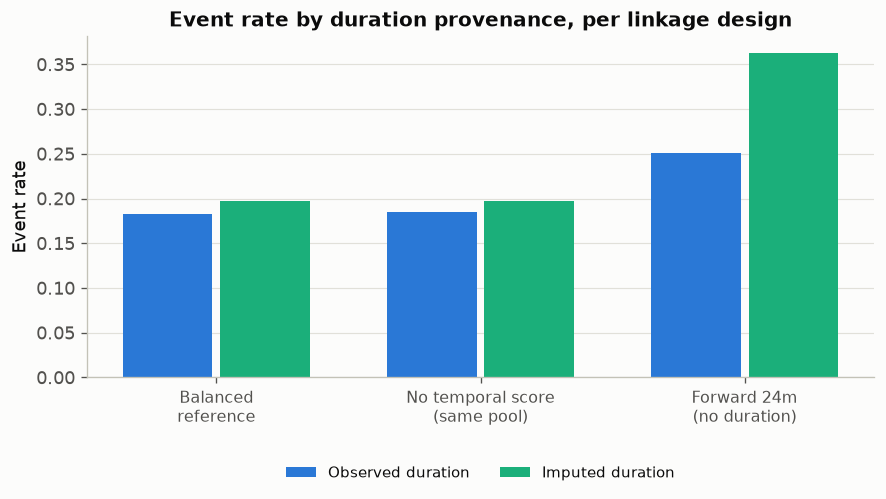

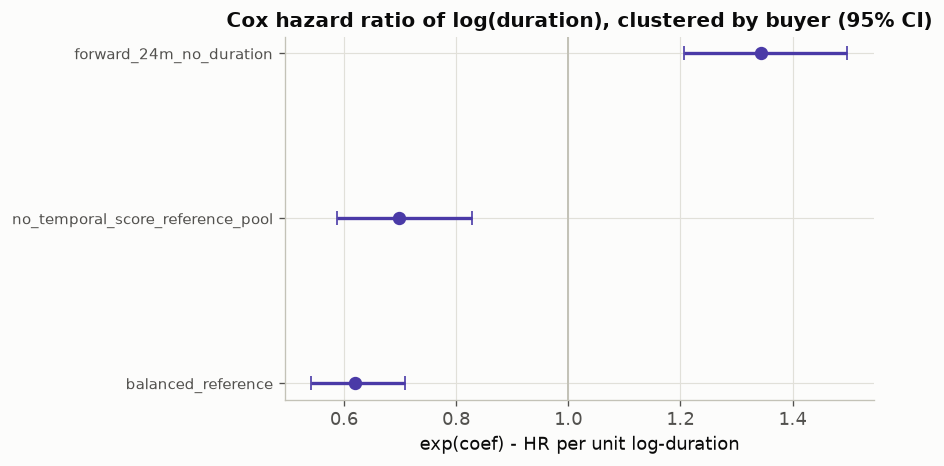

In [9]:
import numpy as np

VARIANT_LABELS = {
    "balanced_reference": "Balanced\nreference",
    "no_temporal_score_reference_pool": "No temporal score\n(same pool)",
    "forward_24m_no_duration": "Forward 24m\n(no duration)",
}

fig, ax = plt.subplots(figsize=(7.5, 4.4))
xpos = np.arange(len(leakage))
w = 0.34
ax.bar(xpos - w / 2 - 0.015, leakage["observed_duration_event_rate"], width=w,
       label="Observed duration", color=CAT["blue"], edgecolor="none")
ax.bar(xpos + w / 2 + 0.015, leakage["imputed_duration_event_rate"], width=w,
       label="Imputed duration", color=CAT["aqua"], edgecolor="none")
ax.set_axisbelow(True)
ax.set_xticks(xpos)
ax.set_xticklabels([VARIANT_LABELS.get(v, v) for v in leakage["variant"]], fontsize=9.5)
ax.set_title("Event rate by duration provenance, per linkage design")
ax.set_ylabel("Event rate")
ax.grid(axis="x")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=9)
save_and_show(fig, "nb15_duration_leakage_event_rates")

fig, ax = plt.subplots(figsize=(7.5, 4))
sub = cox_df[(cox_df.term == "log_duration") & (cox_df.model == "cox_duration_clustered")]
ax.errorbar(sub["exp_coef"], np.arange(len(sub)),
            xerr=[sub["exp_coef"] - sub["ci_lower"], sub["ci_upper"] - sub["exp_coef"]],
            fmt="o", color=CAT["violet"], ecolor=CAT["violet"], capsize=4, markersize=7, linewidth=2)
ax.axvline(1.0, color=BASELINE, linewidth=1.2)
ax.set_yticks(np.arange(len(sub)))
ax.set_yticklabels(sub["variant"], fontsize=9)
ax.set_title("Cox hazard ratio of log(duration), clustered by buyer (95% CI)")
ax.set_xlabel("exp(coef) - HR per unit log-duration")
save_and_show(fig, "nb15_cox_duration_hr")